In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from typing import TypedDict, Annotated
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from pydantic import BaseModel , Field
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate
import operator

/Users/tajbirhasanshuvo/micromamba/envs/genai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation",
    temperature=0
)

model = ChatHuggingFace(llm=llm)

In [4]:
class EvalSchema(BaseModel):
    
    feedback: str = Field(description="Detailed feedback for the essay")
    score : int = Field(description="Score out of 10", ge=0, le=10)

In [5]:
parser = PydanticOutputParser(pydantic_object=EvalSchema)

In [6]:
template = PromptTemplate(
    template=(
        "Evaluate the language quality of the essay.\n Return ONLY a valid JSON object and NOTHING ELSE.\n Do not add explanations.\n\n Essay:\n{essay}\n\n {format_instruction}\n JSON:"
    ),
    input_variables=['essay'],
    partial_variables={'format_instruction': parser.get_format_instructions()}
)

In [34]:
essay = """
Human thought is the seed from which both discovery and creation bloom. It is through thought that man perceives, interprets, and transforms his world. The statement – “Thought finds a world and creates one also” – beautifully encapsulates this dual capacity of human consciousness. Thought acts as both a mirror reflecting the pre-existing truths of the universe and as a lamp illuminating new realities born of imagination, innovation, and creativity. This duality – of discovery and creation – is what has shaped human civilization, philosophy, science, and culture across ages. At the heart of this idea lies a profound paradox: thought does not merely exist within the world; it constructs the very frameworks through which the world is known and transformed. Understanding this dual role of thought provides deeper insight into how humanity advances – by uncovering eternal truths that already exist and by creating novel possibilities that redefine existence itself. 

Human thought, at its most analytical, functions as a discovery mechanism – revealing patterns, laws, and truths that exist independently of human perception. It allows the mind to act as an archaeologist of truth, uncovering hidden realities embedded in nature and existence. The scientific method epitomizes thought’s capacity to find a world. When Newton articulated the law of gravitation, he did not invent gravity – he merely discovered a cosmic truth that had governed the motion of planets long before his time. Similarly, Darwin’s theory of evolution revealed biological processes that existed for millions of years, hidden until human curiosity brought them to light. Indian contributions, too, highlight this intellectual discovery. Aryabhata’s computation of pi or Sushruta’s revelation of surgical anatomy were not creations ex nihilo but insights into universal truths that pre-existed human awareness. Mathematics also embodies thought’s purest discovery function. Prime numbers, geometric relationships, and ratios exist as universal constants, awaiting recognition. When Ramanujan intuited infinite series and modular equations, he was discovering deep mathematical realities rather than fabricating them. Numbers, like truths, are discovered, not invented. Medical science has repeatedly demonstrated this uncovering tendency. The circulation of blood existed before William Harvey explained it. Germs caused disease before Pasteur identified them. The Indian treatise Charaka Samhita revealed physiological and medicinal knowledge that reflected close observation of natural laws rather than creative invention. In this sense, thought functions as the explorer of reality’s hidden terrain. 

Yet, human thought is not limited to discovering what exists – it creates what never was. It constructs worlds of meaning, systems of governance, works of art, and technologies that transform both individual and collective experience. If discovery is thought of as an analytical function, creation is its imaginative and constructive one. Language is perhaps humanity’s greatest creative invention. It constructs meaning systems, conceptual categories, and emotional nuances that shape perception itself. Sanskrit, through Panini’s Ashtadhyayi, created sophisticated grammar that became a tool not only for communication but for intellectual creation. Languages don’t merely describe reality – they create it. In art, thought manifests its power to create new experiences. When a musician composes a raga or when the Taj Mahal transforms marble into emotion, thought transcends the physical and gives form to the intangible. The artist does not discover beauty; they create it. Art, therefore, becomes thought’s playground – where imagination crafts worlds that move the human spirit. From the wheel to artificial intelligence, technology illustrates thought’s capacity to reshape existence. The invention of zero by Indian mathematicians was not the discovery of a physical reality but the creation of a conceptual revolution. Likewise, digital technologies and space exploration represent humanity’s ability to create virtual and cosmic worlds that extend far beyond immediate experience. The Indian Space Research Organisation (ISRO) exemplifies this synthesis of thought’s creative force – creating technologies that open up new frontiers while uncovering truths about the universe. 

Social and political structures – democracy, capitalism, socialism – are creations of thought that organize human behavior. Democracy did not exist as a natural law; it was conceived by thinkers who imagined a just political order. Conversely, social constructs like caste or class hierarchies, though artificial, demonstrate thought’s power to shape lived reality – for better or worse. Thought also creates systems of meaning. The Buddha’s reflections on suffering and liberation gave birth to Buddhism – an entire world of spiritual practice and moral philosophy. Similarly, Vedanta’s concept of Brahman and Atman created metaphysical frameworks that continue to guide Indian consciousness. These ideas didn’t merely describe reality; they constructed new ways of perceiving and living it. 

While discovery and creation appear distinct, in truth they are deeply intertwined. Every discovery involves an act of creative interpretation, and every creation is rooted in some discovery of existing potential. When Einstein formulated the theory of relativity, he discovered natural laws but also created new conceptual frameworks for understanding time and space. Similarly, S.N. Bose in quantum mechanics both discovered quantum behavior and created new mathematical tools for its description. Thought thus blurs the boundary between finding and making. Different cultures interpret reality through unique conceptual frameworks, showing how thought shapes what it perceives or “finds.” The Indian idea of cyclical time contrasts with the Western linear conception – two distinct worlds created by thought, yet both attempting to understand the same reality. Thus, every perception is both discovery and construction. Modern physics itself acknowledges this paradox. The “observer effect” in quantum mechanics suggests that observation alters reality – implying that consciousness participates in creation even as it seeks to discover. This philosophical implication erases the neat line between objective finding and subjective making. 

In addressing climate change, thought discovers atmospheric patterns and ecological interdependencies while creating renewable energy technologies and international policy frameworks. Indian solar missions and community-based sustainability models illustrate how discovery and creation operate in tandem for planetary survival. During the COVID-19 crisis, humanity discovered viral behavior and genetic structures while creating vaccines, public health strategies, and social systems of resilience. Indian scientists and pharmaceutical innovators embodied this dual function, finding biological truths and creating mechanisms for their management. Artificial intelligence perhaps best demonstrates thought’s dual role today. Algorithms discover patterns in vast datasets but also create new realities – from virtual assistants to autonomous machines that can think independently. Human thought here mirrors itself, simultaneously creating tools that reflect its own essence. Digital platforms created new social worlds that revealed previously hidden aspects of human behavior – attention dynamics, conformity, aggression, and empathy. Thus, by creating virtual spaces, thought also discovered deep truths about the human psyche. In venturing beyond Earth, humanity both discovers cosmic phenomena and creates technologies – rockets, satellites, and space stations – that make exploration possible. India’s Chandrayaan and Mangalyaan missions beautifully embody this fusion of finding and creating. 

Philosophers like Friedrich Nietzsche argued, “There are no facts, only interpretations.” This challenges the notion of pure discovery, suggesting that all human knowledge is mediated through perception and language – which are themselves creations. In this sense, even when thought “finds,” it does so through conceptual lenses it has already made. Similarly, linguistic relativity – the idea that language shapes thought – implies that we never access an objective world directly. The Sanskrit concept of Dharma, with its layered meanings of duty, law, and cosmic order, cannot be fully translated, showing how language creates the world it describes. Thus, the act of knowing itself is creative; thought is not a passive receiver of reality but an active participant in its construction. 

To ensure that thought continues to be found and created ethically, humanity must cultivate critical thinking, scientific temper, and moral imagination. Education must encourage inquiry as well as creativity. Policymakers should combine evidence-based discovery with visionary creation of inclusive institutions. Technology must serve humanity’s higher ideals, not enslave it. The Indian philosophical vision of Vasudhaiva Kutumbakam – “the world is one family” – exemplifies thought’s highest synthesis: discovering universal connectedness while creating a moral world that embodies it. 

The journey of civilization is the story of thought, both finding and creating the world. From the discovery of fire to the creation of cyberspace, from the Upanishadic search for truth to the algorithms of artificial intelligence, thought has served as both compass and chisel – revealing what is and shaping what can be. Ultimately, human consciousness is both mirror and lamp – reflecting the universe and illuminating new paths within it. As long as thought continues to explore and imagine, humanity will remain both student and sculptor of its own destiny. In discovering the world and creating one also, we fulfill the deepest function of being human – to understand, to transform, and to transcend.
"""

In [8]:
prompt = template.invoke({'essay':essay})

In [9]:
result =model.invoke(prompt).content

In [10]:
print(result)

{
  "feedback": "The essay provides a well-structured and coherent argument on the dual role of human thought in discovery and creation. It effectively uses examples from science, art, technology, and philosophy to support its claims. However, some sentences could be rephrased for better clarity, and the essay could benefit from more nuanced analysis of the complexities of thought and its relationship with reality.",
  "score": 8
}


In [11]:
import json
import re

def extract_json(text):
    match = re.search(r"\{[\s\S]*\}", text)
    if not match:
        raise ValueError("No JSON found in output")
    return json.loads(match.group())

In [12]:
data = extract_json(result)
validated = EvalSchema(**data)

print(validated)


feedback='The essay provides a well-structured and coherent argument on the dual role of human thought in discovery and creation. It effectively uses examples from science, art, technology, and philosophy to support its claims. However, some sentences could be rephrased for better clarity, and the essay could benefit from more nuanced analysis of the complexities of thought and its relationship with reality.' score=8


In [13]:
validated.score

8

In [27]:
class EssayState(TypedDict):
    
    essay:str
    language_feedback : str
    analysis_feedback:str
    clarity_feedback: str
    overall_feedback:str
    
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float

In [28]:
def evaluate_language(state: EssayState):
    
    template = PromptTemplate(
        template=(
            "Evaluate the language quality of the essay.\n Return ONLY a valid JSON object and NOTHING ELSE.\n Do not add explanations.\n\n Essay:\n{essay}\n\n {format_instruction}\n JSON:"
        ),
        input_variables=['essay'],
        partial_variables={'format_instruction': parser.get_format_instructions()}
    )
    
    prompt = template.invoke({'essay':state['essay']})
    
    result = model.invoke(prompt).content
    data = extract_json(result)
    validated = EvalSchema(**data)
    
    return {'language_feedback':validated.feedback, 'individual_scores':[validated.score]}

In [29]:
def evaluate_analysis(state: EssayState):
    
    template = PromptTemplate(
        template=(
            "Evaluate the depth of analysis of the essay.\n Return ONLY a valid JSON object and NOTHING ELSE.\n Do not add explanations.\n\n Essay:\n{essay}\n\n {format_instruction}\n JSON:"
        ),
        input_variables=['essay'],
        partial_variables={'format_instruction': parser.get_format_instructions()}
    )
    
    prompt = template.invoke({'essay':state['essay']})
    
    result = model.invoke(prompt).content
    data = extract_json(result)
    validated = EvalSchema(**data)
    
    return {'analysis_feedback':validated.feedback, 'individual_scores':[validated.score]}

In [30]:
def evaluate_clarity(state: EssayState):
    
    template = PromptTemplate(
        template=(
            "Evaluate the clarity of thought of the essay.\n Return ONLY a valid JSON object and NOTHING ELSE.\n Do not add explanations.\n\n Essay:\n{essay}\n\n {format_instruction}\n JSON:"
        ),
        input_variables=['essay'],
        partial_variables={'format_instruction': parser.get_format_instructions()}
    )
    
    prompt = template.invoke({'essay':state['essay']})
    
    result = model.invoke(prompt).content
    data = extract_json(result)
    validated = EvalSchema(**data)
    
    return {'clarity_feedback':validated.feedback, 'individual_scores':[validated.score]}

In [31]:
def final_evaluate(state: EssayState):
    
    prompt = f"Based on the following feedbacks create a summarized feedback \n language feedback : {state['language_feedback']}\n analysis feedback : {state['analysis_feedback']}\n though of clarity feedback: {state['clarity_feedback']}"
    
    overall = model.invoke(prompt).content
    
    avg = sum(state['individual_scores'])/len(state['individual_scores'])
    
    return {'overall_feedback':overall , 'avg_score':avg}

In [32]:
graph = StateGraph(EssayState)

graph.add_node('evaluate_language',evaluate_language)
graph.add_node('evaluate_analysis',evaluate_analysis)
graph.add_node('evaluate_clarity',evaluate_clarity)
graph.add_node('final_evaluate',final_evaluate)

graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_clarity')

graph.add_edge( 'evaluate_language', 'final_evaluate')
graph.add_edge( 'evaluate_analysis', 'final_evaluate')
graph.add_edge( 'evaluate_clarity', 'final_evaluate')

graph.add_edge('final_evaluate', END)

workflow = graph.compile()


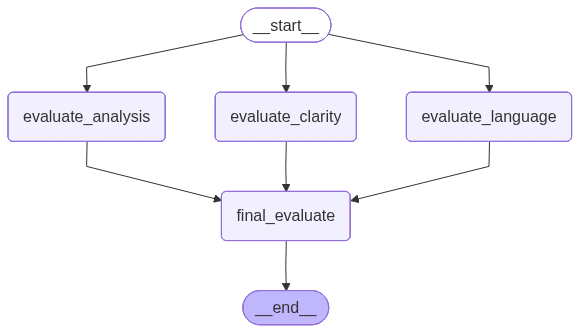

In [33]:
workflow

In [37]:
essay="""
My Country Bangladesh

My country name is Bangladesh. It is a small country but it have large population. Bangladesh is in South Asia. It become independent in 1971 after a bloody war. Many people give their life for the freedom of this country. I feel proud for my country.

Bangladesh is a river country. There are many river like Padma, Jamuna and Meghna. These rivers make our land fertile. Most of the people of Bangladesh are farmer. They work very hard but they do not earn much money. Rice is the main food of Bangladeshi people. Fish is also very popular food here.

The weather of Bangladesh is hot and humid. There are six season in Bangladesh. They are summer, rainy, autumn, late autumn, winter and spring. Rainy season bring much rain and sometimes flood happen. Flood cause many problem to poor people.

People of Bangladesh are simple and friendly. They love guest very much. We have many culture and tradition. Pahela Baishakh is our main festival. We celebrate it happily. We also celebrate Eid and other religious festival with joy.

Though Bangladesh have many problem like poverty, corruption and unemployment, it is developing day by day. Many garment factory earn foreign money for our country. I hope Bangladesh will be a developed country in future.

I love my country very much.
"""

In [38]:
init_state= {
    'essay':essay
}

result = workflow.invoke(init_state)

In [39]:
result

{'essay': '\nMy Country Bangladesh\n\nMy country name is Bangladesh. It is a small country but it have large population. Bangladesh is in South Asia. It become independent in 1971 after a bloody war. Many people give their life for the freedom of this country. I feel proud for my country.\n\nBangladesh is a river country. There are many river like Padma, Jamuna and Meghna. These rivers make our land fertile. Most of the people of Bangladesh are farmer. They work very hard but they do not earn much money. Rice is the main food of Bangladeshi people. Fish is also very popular food here.\n\nThe weather of Bangladesh is hot and humid. There are six season in Bangladesh. They are summer, rainy, autumn, late autumn, winter and spring. Rainy season bring much rain and sometimes flood happen. Flood cause many problem to poor people.\n\nPeople of Bangladesh are simple and friendly. They love guest very much. We have many culture and tradition. Pahela Baishakh is our main festival. We celebrate 